# Separate solver error from mesh error
### Iterative convergence, discretization, and an error budget

This notebook separates the error from an unfinished iterative solve from the error introduced by the spatial discretization. A manufactured one-dimensional conduction problem provides an analytic reference; inputs are synthetic educational data.

**Targets:** direct-solve observed order between 1.9 and 2.1 when the mesh is halved, and iterative error below 1% of discretization error at the strict tolerance on both meshes.

Run the cells from top to bottom with a Python kernel containing NumPy, Matplotlib, and IPython. All solver code is included here.

**Notation:** $\theta_J$ is the Jacobi iterate, $\theta_D$ is the direct solution of the discrete system, and $\theta^*$ is the analytic solution. Their differences isolate iterative, discretization, and total error.

## 1. Governing equation and manufactured solution

For a constant-area slab with constant conductivity and no advection or radiation,

$$-k\frac{d^2T}{dx^2}=q'''(x),\qquad 0<x<L,$$
$$L=0.10\,\mathrm{m},\qquad k=10\,\mathrm{W\,m^{-1}\,K^{-1}},\qquad T(0)=T(L)=300\,\mathrm{K}.$$

Introduce the dimensionless coordinate and temperature,

$$\xi=\frac{x}{L},\qquad \theta=\frac{T-300\,\mathrm{K}}{10\,\mathrm{K}}.$$

The manufactured dimensionless problem is

$$-\frac{d^2\theta}{d\xi^2}=\pi^2\sin(\pi\xi),\qquad \theta(0)=\theta(1)=0,$$
$$\theta^*(\xi)=\sin(\pi\xi).$$

Substitution into the dimensional equation gives

$$q'''(x)=k(10\,\mathrm{K})\left(\frac{\pi}{L}\right)^2\sin\left(\frac{\pi x}{L}\right),$$

with units $\mathrm{W\,m^{-3}}$. The source comes from the continuous manufactured solution, independently of the numerical stencil.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

L = 0.10
CONDUCTIVITY = 10.0
T_BOUNDARY = 300.0
TEMPERATURE_SCALE = 10.0
MESHES = (20, 40)  # equal intervals
TOLERANCES = (1e-2, 1e-4, 1e-6)
MAX_ITERATIONS = 20_000

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2. Discretization and boundary conditions

Use $N$ equal intervals, $N+1$ nodes, and spacing $h=1/N$ in the dimensionless coordinate. At each interior node,

$$-\frac{\theta_{i-1}-2\theta_i+\theta_{i+1}}{h^2}=\pi^2\sin(\pi\xi_i).$$

The interior linear system is $A\theta_{\mathrm{int}}=b$, with diagonal entries $2/h^2$, adjacent entries $-1/h^2$, and

$$b_i=\pi^2\sin(\pi\xi_i).$$

Only the $N-1$ interior temperatures are unknown; both boundary values are fixed at zero. The mesh spacing used in the matrix must match the coordinates returned for the $N+1$ nodes.

In [2]:
def exact_solution(xi):
    """Return the exact dimensionless solution at the given coordinates."""
    return np.sin(np.pi * xi)


def build_system(intervals):
    """Return coordinates, interior matrix/vector, and exact nodal values."""
    xi = np.linspace(0.0, 1.0, intervals + 1)
    h = 1.0 / intervals
    interior_count = intervals - 1
    A = (2.0 * np.eye(interior_count)
         - np.eye(interior_count, k=1)
         - np.eye(interior_count, k=-1)) / h**2
    b = np.pi**2 * np.sin(np.pi * xi[1:-1])
    exact = exact_solution(xi)
    return xi, A, b, exact


def with_endpoints(interior):
    """Restore prescribed zero boundary values for plots and checks."""
    return np.concatenate(([0.0], interior, [0.0]))


def normalized_residual(A, theta, b):
    return np.linalg.norm(b - A @ theta, ord=np.inf) / np.linalg.norm(b, ord=np.inf)


def jacobi(A, b, tol, max_iterations=MAX_ITERATIONS):
    """Return the interior solution, residual history, and convergence flag."""
    theta = np.zeros_like(b, dtype=float)
    diagonal = np.diag(A)
    off_diagonal = A - np.diag(diagonal)
    history = [normalized_residual(A, theta, b)]

    for _ in range(max_iterations):
        theta_new = (b - off_diagonal @ theta) / diagonal
        theta = theta_new
        history.append(normalized_residual(A, theta, b))
        if history[-1] < tol:
            return theta, np.asarray(history), True
    return theta, np.asarray(history), False

## 3. Error measures and solver stopping

Compare three solutions on the same mesh: the Jacobi iterate $\theta_J$, the direct linear-system solution $\theta_D$, and the analytic solution $\theta^*$. Define

$$e_{\mathrm{iter}}=\|\theta_J-\theta_D\|_\infty,\qquad e_{\mathrm{disc}}=\|\theta_D-\theta^*\|_\infty,$$
$$e_{\mathrm{total}}=\|\theta_J-\theta^*\|_\infty.$$

The signed vectors satisfy

$$(\theta_J-\theta_D)+(\theta_D-\theta^*)=\theta_J-\theta^*.$$

Opposing components can cancel, so the total error need not equal the sum of the component norms. For the direct-solve discretization error, second-order behavior predicts

$$p=\frac{\log[E(N)/E(2N)]}{\log 2}\approx 2.$$

A normalized residual measures how closely an iterate solves the discrete equations; by itself it does not measure either discretization error or solution error.

In [3]:
def signed_error_vectors(iterative, direct, exact):
    """Return signed iterative, discretization, and total error vectors."""
    iterative_error = iterative - direct
    discretization_error = direct - exact
    total_error = iterative - exact
    return iterative_error, discretization_error, total_error


def error_metrics(iterative, direct, exact):
    """Return infinity norms for iterative, discretization, and total error."""
    iterative_error = np.linalg.norm(iterative - direct, ord=np.inf)
    discretization_error = np.linalg.norm(direct - exact, ord=np.inf)
    total_error = np.linalg.norm(iterative - exact, ord=np.inf)
    return {
        "iterative": iterative_error,
        "discretization": discretization_error,
        "total": total_error,
    }

## 4. Numerical experiment and convergence

Run Jacobi on $N=20$ and $N=40$ intervals with three residual tolerances. For each mesh, compare every iterate with both the direct solution and the analytic solution.

**Deliverable:** a six-row table containing residual, update count, convergence status, all three error measures, and the iterative-to-discretization error ratio. Check that halving $h$ reduces the direct-solve error by roughly four, then compare the strict-tolerance iterative error with the discretization error.

In [4]:
results = []
solutions = {}
residual_histories = {}
direct_errors = {}

for intervals in MESHES:
    xi, A, b, exact = build_system(intervals)
    direct = with_endpoints(np.linalg.solve(A, b))
    direct_errors[intervals] = np.linalg.norm(direct - exact, ord=np.inf)

    for tol in TOLERANCES:
        interior, history, converged = jacobi(A, b, tol)
        iterative = with_endpoints(interior)
        errors = error_metrics(iterative, direct, exact)
        results.append({
            "N": intervals,
            "tolerance": tol,
            "iterations": len(history) - 1,
            "residual": history[-1],
            "converged": converged,
            **errors,
            "iter/disc": errors["iterative"] / errors["discretization"],
        })
        solutions[intervals, tol] = (xi, iterative, direct, exact)
        residual_histories[intervals, tol] = history

table = [
    "| N | Tolerance | Updates | Residual | Iterative error | Discretization error | Total error | Iter/Disc | Converged |",
    "|---:|---:|---:|---:|---:|---:|---:|---:|:---:|",
]
for row in results:
    table.append(
        f"| {row['N']} | {row['tolerance']:.0e} | {row['iterations']} "
        f"| {row['residual']:.3e} | {row['iterative']:.3e} "
        f"| {row['discretization']:.3e} | {row['total']:.3e} "
        f"| {row['iter/disc']:.3e} | {row['converged']} |"
    )
display(Markdown("\n".join(table)))

error_ratio = direct_errors[MESHES[0]] / direct_errors[MESHES[1]]
observed_order = np.log(error_ratio) / np.log(MESHES[1] / MESHES[0])
print(f"Direct error ratio E20/E40: {error_ratio:.4f}; observed order: {observed_order:.4f}")
for row in results:
    if row["tolerance"] == min(TOLERANCES):
        passed = row["converged"] and row["iter/disc"] < 0.01
        print(f"N={row['N']}: strict-tolerance target {'PASS' if passed else 'FAIL'}")

| N | Tolerance | Updates | Residual | Iterative error | Discretization error | Total error | Iter/Disc | Converged |
|---:|---:|---:|---:|---:|---:|---:|---:|:---:|
| 20 | 1e-02 | 372 | 9.968e-03 | 9.989e-03 | 2.059e-03 | 7.930e-03 | 4.852e+00 | True |
| 20 | 1e-04 | 744 | 9.936e-05 | 9.957e-05 | 2.059e-03 | 1.959e-03 | 4.836e-02 | True |
| 20 | 1e-06 | 1116 | 9.905e-07 | 9.925e-07 | 2.059e-03 | 2.058e-03 | 4.821e-04 | True |
| 40 | 1e-02 | 1492 | 9.987e-03 | 9.992e-03 | 5.142e-04 | 9.478e-03 | 1.943e+01 | True |
| 40 | 1e-04 | 2984 | 9.975e-05 | 9.980e-05 | 5.142e-04 | 4.144e-04 | 1.941e-01 | True |
| 40 | 1e-06 | 4475 | 9.993e-07 | 9.998e-07 | 5.142e-04 | 5.132e-04 | 1.944e-03 | True |

Direct error ratio E20/E40: 4.0037; observed order: 2.0013
N=20: strict-tolerance target PASS
N=40: strict-tolerance target PASS


## 5. Solution, signed errors, and residual history

Inspect the analytic solution, direct solution, and strict-tolerance Jacobi iterate on the finest mesh. The second panel separates signed iterative and discretization errors and shows their sum; the third panel shows how the normalized residual changes with updates.

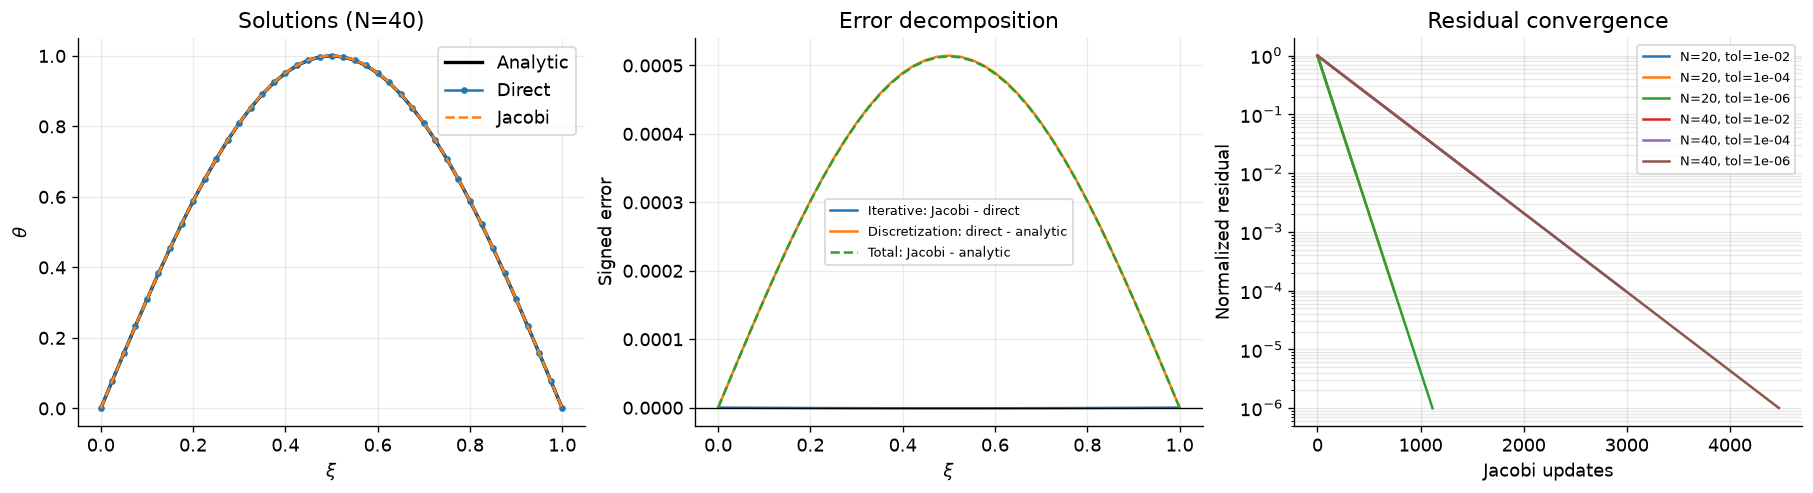

In [5]:
intervals = MESHES[-1]
tol = min(TOLERANCES)
xi, iterative, direct, exact = solutions[intervals, tol]
iterative_vector, discretization_vector, total_vector = signed_error_vectors(
    iterative, direct, exact
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
axes[0].plot(xi, exact, color="black", lw=2, label="Analytic")
axes[0].plot(xi, direct, "o-", ms=3, label="Direct")
axes[0].plot(xi, iterative, "--", lw=1.5, label="Jacobi")
axes[0].set(xlabel=r"$\xi$", ylabel=r"$\theta$", title=f"Solutions (N={intervals})")
axes[0].legend()

axes[1].plot(xi, iterative_vector, label="Iterative: Jacobi - direct")
axes[1].plot(xi, discretization_vector, label="Discretization: direct - analytic")
axes[1].plot(xi, total_vector, "--", label="Total: Jacobi - analytic")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(xlabel=r"$\xi$", ylabel="Signed error", title="Error decomposition")
axes[1].legend(fontsize=8)

for (mesh, tolerance), history in residual_histories.items():
    axes[2].semilogy(np.arange(len(history)), history,
                     label=f"N={mesh}, tol={tolerance:.0e}")
axes[2].set(xlabel="Jacobi updates", ylabel="Normalized residual",
            title="Residual convergence")
axes[2].grid(True, which="both", alpha=0.3)
axes[2].legend(fontsize=8)

for ax in axes[:2]:
    ax.grid(alpha=0.25)
plt.show()

## 6. Automatic checks

Enforce second-order direct-solve behavior, strict-tolerance solver accuracy, fixed boundaries, symmetry, and the signed-error identity.

In [6]:
assert all(row["converged"] for row in results)
assert 1.9 <= observed_order <= 2.1

strict_rows = [row for row in results if row["tolerance"] == min(TOLERANCES)]
assert len(strict_rows) == len(MESHES)
assert all(row["iter/disc"] < 0.01 for row in strict_rows)

for (intervals, tol), (xi, iterative, direct, exact) in solutions.items():
    assert iterative[0] == iterative[-1] == 0.0
    np.testing.assert_allclose(iterative, iterative[::-1], rtol=0, atol=1e-12)
    np.testing.assert_allclose(direct, direct[::-1], rtol=0, atol=1e-12)
    iterative_vector, discretization_vector, total_vector = signed_error_vectors(
        iterative, direct, exact
    )
    np.testing.assert_allclose(
        iterative_vector + discretization_vector, total_vector, rtol=1e-12, atol=1e-14
    )

print("PASS: convergence order, iterative-error targets, residual convergence, boundaries, symmetry, and error decomposition.")

PASS: convergence order, iterative-error targets, residual convergence, boundaries, symmetry, and error decomposition.


## 7. Discussion and next steps

### Interpreting the error budget

- **Iterative error** measures how far Jacobi remains from the exact solution of the discrete equations. Tightening the stopping tolerance should reduce it.
- **Discretization error** remains in the direct solution because the finite-difference equations only approximate the differential equation. It decreases under mesh refinement even when the linear system is solved to machine precision.
- **Total error** is the signed sum of the two error vectors. Cancellation can make its norm smaller than either component, so inspect the signed plot as well as the table.
- **A residual threshold is not a universal error guarantee.** The residual is tied to the discrete system and its scaling; the relationship between residual and solution error also depends on the matrix. Here, compare iterative error directly with the discretization error to choose a meaningful stopping target.

### Scope

This is a smooth, one-dimensional, constant-conductivity verification problem on uniform meshes. It does not establish accuracy for variable material properties, complex geometry, nonlinear boundary conditions, or experimental data.

### Reading and extension

Read Sections 3.2.1 and 3.2.3 of Oberkampf & Trucano (2002), *Verification and Validation in Computational Fluid Dynamics*, SAND2002-0529, [full report](https://www.osti.gov/servlets/purl/793406), and the [NASA iterative convergence discussion](https://www.grc.nasa.gov/www/wind/valid/tutorial/iterconv.html). Then add a finer mesh or a tighter tolerance and predict which error component should change before rerunning the experiment.